# 线性SVM

---

### 1. 线性 SVM 分类：大间隔分类器

线性 SVM 的目标是在两类数据之间画一条线（在高维空间中是一个超平面），使得这条线到最近训练实例的距离最大化。

* **间隔（Margin）**：分类边界与最近训练实例之间的距离。
* **支持向量（Support Vectors）**：恰好位于“街道”边缘的那些实例。
* 决定决策边界的**仅有**这些支持向量。
* 在“街道”之外添加更多实例不会改变边界，只要它们不跨越边缘。

---

### 2. 硬间隔分类 (Hard Margin Classification)

如果我们严格规定所有实例都必须落在“街道”之外且位于正确的一侧，这就是**硬间隔分类**。

* **局限性**：
1. **线性可分限制**：只适用于数据可以被完美分开的情况。
2. **异常值敏感**：即便数据线性可分，一个靠近另一类群体的异常值（Outlier）也会导致“街道”变得非常窄，或者根本无法找到解。

---

### 3. 软间隔分类 (Soft Margin Classification)

为了克服硬间隔的脆性，我们需要一个更灵活的模型。**软间隔分类**的目标是在“保持街道尽可能宽”与“限制间隔违规（即点出现在街道中央甚至错误一侧）”之间找到一个平衡。

* **超参数 $C$ 的权衡**：
* **低 $C$ 值**：模型倾向于拥有更宽的街道，即使这意味着更多的间隔违规。这种做法通常具有更好的**泛化能力**，因为它对单个异常值的敏感度较低。
* **高 $C$ 值**：模型会非常努力地减少间隔违规，导致街道变窄。这可能导致**过拟合**，因为模型过度拟合了训练集中的每一个细节。
---


In [2]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

iris = datasets.load_iris()
X = iris['data'][:,(2,3)]
y = (iris['target']==2).astype(np.float64)

svm_clf = Pipeline((
    ('scaler', StandardScaler()),
    ('linear_svc',LinearSVC(C = 1,loss='hinge')),
))
svm_clf.fit(X,y)

,steps,"[('scaler', ...), ('linear_svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001


In [3]:
svm_clf.predict([[5.5,1.7]])

array([1.])

# 非线性SVM分类

线性 SVM 虽然高效，但现实中很多数据集并不是线性可分的。
处理非线性数据的一个直观方法就是添加**多项式特征**（Polynomial Features）。

---

### 1. 核心原理：升维打击

多项式特征的思想非常朴素：如果数据在当前维度无法用直线分开，我们就把数据投影到更**高维**的空间中，使其变得线性可分。

* **简单例子**：想象在一条直线（一维）上，有一些红点被两边的蓝点包围，无法用一个点（一维的决策边界）把它们分开。
* **升维方案**：给每个数据添加一个特征 $x^2$。现在数据变成了二维的。这些点现在分布在一条抛物线上，很轻易地就能画一条直线将红蓝两类切开。

---

### 3. 多项式特征的优缺点

* **优点**：方法简单通用，对于各种机器学习算法都有效，不局限于 SVM。
* **缺点**：
* **特征爆炸**：如果多项式阶数（degree）很高，特征数量会急剧增加（组合爆炸），导致模型运行速度变得极慢。
* **维数灾难**：过多的特征容易导致模型过拟合。

---

In [4]:
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

X,y = make_moons(n_samples=100, noise=0.15,random_state=42)

polynomial_svm_clf = Pipeline((
    ('poly_features', PolynomialFeatures(degree=3)),
    ('scaler', StandardScaler()),
    ('svm_clf',LinearSVC(C = 1,loss='hinge'))
))
polynomial_svm_clf.fit(X,y)

,steps,"[('poly_features', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,copy,True
,with_mean,True
,with_std,True


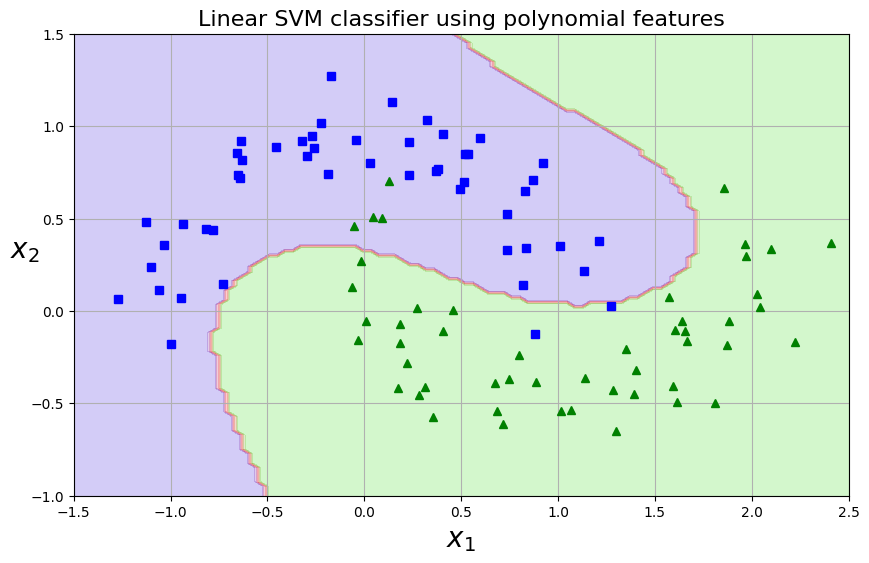

In [7]:
import matplotlib.pyplot as plt
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X_new).reshape(x0.shape)
    y_decision = clf.decision_function(X_new).reshape(x0.shape)

    # 绘制填充色带，展现分类区域
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs") # 蓝色方块
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^") # 绿色三角
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

# 3. 执行绘图
plt.figure(figsize=(10, 6))
plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title("Linear SVM classifier using polynomial features", fontsize=16)
plt.show()

## 多项式核

手动添加高阶多项式特征会导致特征数量爆炸。而**核技巧（Kernel Trick）**能产生与添加高阶多项式完全相同的数学结果，却不需要真的增加任何特征。

---

### 1. 核心原理：

核技巧通过一个特殊的数学函数（核函数），直接计算出在高维空间中两个向量的点积，而不需要先进行升维转换。

* **手动方法**：原始数据 $\to$ 计算多项式组合项（生成海量特征） $\to$ 线性 SVM 训练。
* **多项式核**：原始数据 $\to$ SVM（使用 `kernel="poly"`） $\to$ 得到结果。
* 它的计算成本只取决于原始特征的数量，而不是升维后的数量。

---

### 2. 关键超参数解析

在使用多项式核时，有三个参数是必须掌握的：

1. **`degree`（阶数）**：
* 决定了你希望多项式有多复杂。
* 如果模型过拟合，减小阶数；如果欠拟合，增加阶数。


2. **`coef0`（偏置项 $r$）**：
* 控制模型受高阶多项式还是低阶多项式的影响程度。
* 在公式 $( \gamma \mathbf{x}^T \mathbf{x}' + r )^d$ 中，$r$ 就是这个 `coef0`。
* **经验谈**：通常设置 `coef0=1` 是个不错的开始。


3. **`C`（惩罚系数）**：
* 依然是那个控制“街道宽度”的超参数。

---

### 如何选择？

* 如果数据集**很小**，手动添加多项式特征（使用 `LinearSVC`）可能更快。
* 如果需要**高阶多项式**或者数据集**特征较多**，务必使用 `SVC(kernel="poly")`。


In [9]:
from sklearn.svm import SVC
poly_kernel_svm_clf = Pipeline((
    ('scaler', StandardScaler()),
    ('scm_clf',SVC(kernel = 'poly',degree = 3,coef0=1,C = 5))
))
poly_kernel_svm_clf.fit(X,y)

,steps,"[('scaler', ...), ('scm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,5
,kernel,'poly'
,degree,3
,gamma,'scale'


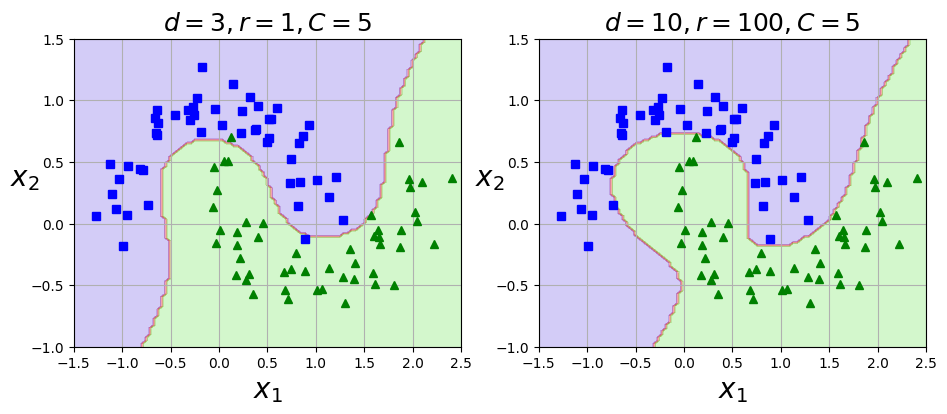

In [11]:
from sklearn.svm import SVC


# 模型 2: 10阶多项式，r=100, C=5
poly100_kernel_svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=10, coef0=100, C=5))
])

# 2. 训练模型
poly100_kernel_svm_clf.fit(X, y)

# 3. 绘图
plt.figure(figsize=(11, 4))

# 左图：d=3, r=1
plt.subplot(121)
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"$d=3, r=1, C=5$", fontsize=18)

# 右图：d=10, r=100
plt.subplot(122)
plot_predictions(poly100_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.title(r"$d=10, r=100, C=5$", fontsize=18)

plt.show()


###  关键细节解析

* **`degree` (d)**：左图阶数为 3，右图为 10。你可以看到右图的决策边界为了拟合复杂的样本点，弯曲程度明显更高。
* **`coef0` (r)**：这个参数控制模型受高阶项还是低阶项的影响。在阶数很高（如 $d=10$）时，设置一个较大的 `coef0`（如 100）可以防止数值计算上的不稳定。
* **过拟合风险**：注意看右图，决策边界变得非常“扭曲”以试图包围每一个绿色三角。如果模型表现出这种特征，说明它可能产生了**过拟合**，此时你应该尝试降低 `degree`。

---

## 添加相似特征

处理非线性问题的另一种强大技术是**添加相似特征（Similarity Features）**。

多项式特征是通过对原始特征进行幂运算来升维，而相似特征则是通过计算每个样本与特定**地标（Landmark）**之间的“相似度”来创建新特征。

---

### 1. 核心思想：地标与相似度函数

想象在地图上标记了几个“地标点”。对于任何一个新位置，不再记录它的经纬度，而是记录它“距离地标 A 有多远”以及“距离地标 B 有多远”。

最常用的相似度函数是 **高斯径向基函数（Gaussian RBF）**：

$$\phi_\gamma(\mathbf{x}, \ell) = \exp(-\gamma \|\mathbf{x} - \ell\|^2)$$

* **$\ell$**：地标点（Landmark）。
* **$\gamma$**：超参数，控制函数的“胖瘦”（即影响范围）。
* **结果**：当样本 $\mathbf{x}$ 靠近地标时，函数值接近 1；当远离地标时，函数值呈钟形衰减至 0。

---

### 2. 它是如何让数据变得线性可分的？

假设有一个一维数据集，其中中间的点是正类，两边的点是负类。通过简单的直线无法分开。

1. 我们在数据集上选定两个地标 $x_1$ 和 $x_2$。
2. 为每个点计算两个新特征：$x'_1 = \text{RBF}(x, \text{地标}_1)$ 和 $x'_2 = \text{RBF}(x, \text{地标}_2)$。
3. 在新的二维空间中，会发现正类点聚集在一起，现在可以画一条直线（超平面）轻松将它们分开了。

---

### 3. 如何选择地标？

最简单的方法是在**数据集中的每个实例位置**都放置一个地标。

* **优点**：这极大地增加了特征维度，从而让找到线性解的机会大大增加。
* **缺点**：如果训练集有 $m$ 个实例、每个实例有 $n$ 个特征，转换后的新数据集将会有 $m$ 个特征（加上原始特征）。如果训练集非常大，特征数量也会变得非常巨大。

---


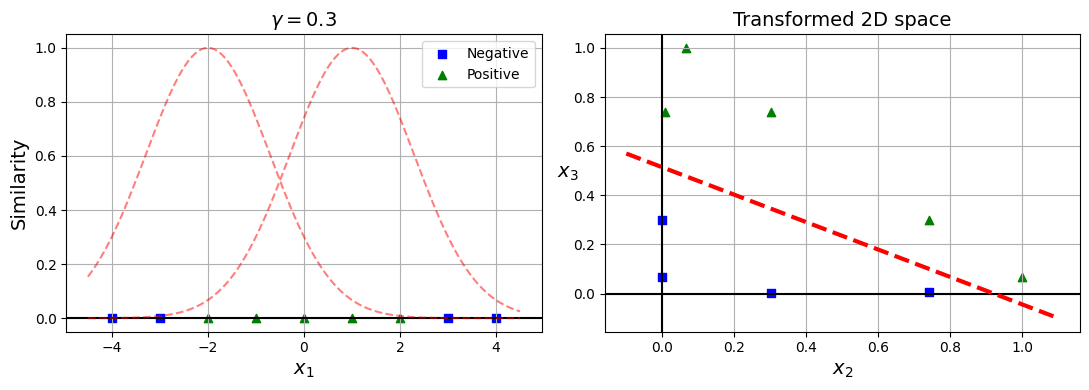

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义高斯 RBF 函数
def gaussian_rbf(x, landmark, gamma):
    return np.exp(-gamma * np.linalg.norm(x - landmark)**2)

# 2. 准备一维数据
X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
y = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0]) # 中间为正类，两边为负类

# 定义地标点
landmarks = [-2, 1]
gamma = 0.3

# 3. 计算新特征 (相似度特征)
X_new = np.empty((len(X1D), 2))
for i, x in enumerate(X1D):
    X_new[i, 0] = gaussian_rbf(x, landmarks[0], gamma)
    X_new[i, 1] = gaussian_rbf(x, landmarks[1], gamma)

# 4. 绘图
plt.figure(figsize=(11, 4))

# --- 左图：一维原始特征与 RBF 曲线 ---
plt.subplot(121)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.scatter(X1D[y==0], np.zeros(len(X1D[y==0])), color='b', marker='s', label="Negative")
plt.scatter(X1D[y==1], np.zeros(len(X1D[y==1])), color='g', marker='^', label="Positive")

# 绘制 RBF 钟形曲线
x_range = np.linspace(-4.5, 4.5, 200).reshape(-1, 1)
for lm in landmarks:
    y_rbf = [gaussian_rbf(val, lm, gamma) for val in x_range]
    plt.plot(x_range, y_rbf, "r--", alpha=0.5)

plt.title(r"$\gamma = 0.3$", fontsize=14)
plt.xlabel(r"$x_1$", fontsize=14)
plt.ylabel("Similarity", fontsize=14)
plt.legend()

# --- 右图：转换后的二维空间 ---
plt.subplot(122)
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.scatter(X_new[y==0, 0], X_new[y==0, 1], color='b', marker='s')
plt.scatter(X_new[y==1, 0], X_new[y==1, 1], color='g', marker='^')

# 绘制决策边界（示意图中的那条虚线）
plt.plot([-0.1, 1.1], [0.57, -0.1], "r--", linewidth=3)

plt.xlabel(r"$x_2$", fontsize=14)
plt.ylabel(r"$x_3$", fontsize=14, rotation=0)
plt.title("Transformed 2D space", fontsize=14)

plt.tight_layout()
plt.show()

---

### 关键图示解析

1. **左图 (相似度度量)**：展示了在 $x_1 = -2$ 和 $x_1 = 1$ 处放置的两个 RBF “地标”。红色虚线显示了相似度如何随距离增加而衰减。
2. **右图 (升维结果)**：这是最神奇的地方。通过 RBF 转换，原本在一根直线上的点被“弹”到了二维平面上。
* 那些原本夹在中间的正类点（绿色三角），现在在新的坐标系中聚集在上方。
* 现在，可以轻易地画出一条**直线（线性超平面）**将它们分开了。

---


## 高斯RBF核函数


---

### 1. 核心公式与直观理解

高斯 RBF 核的数学表达式如下：

$$K(\mathbf{a}, \mathbf{b}) = \exp(-\gamma \|\mathbf{a} - \mathbf{b}\|^2)$$

可以把它想象成一个**钟形曲线**（高斯分布）。

* 当两个样本 $\mathbf{a}$ 和 $\mathbf{b}$ 非常接近时，核函数值接近 1。
* 当它们距离很远时，值迅速下降到 0。
* 它本质上是在衡量样本间的**相似度**。

---

### 2. 关键超参数：$\gamma$ (Gamma)

除了惩罚系数 $C$ 外，$\gamma$ 是 RBF 核最重要的“调节旋钮”。它决定了每个样本的影响范围。

* **较大的 $\gamma$**：
* 钟形曲线更窄。
* 每个实例的影响范围变小，决策边界会变得非常扭曲，围着单个实例转。
* 容易导致**过拟合**（Overfitting）。

* **较小的 $\gamma$**：
* 钟形曲线更宽，更平滑。
* 实例的影响范围更广，决策边界变得更平滑。
* 容易导致**欠拟合**（Underfitting）。

---

### 调参

如果发现模型表现不佳，可以遵循以下逻辑进行调整：

1. **模型过拟合**：降低 $\gamma$（使边界平滑）或减小 $C$（增加正则化）。
2. **模型欠拟合**：提高 $\gamma$（使边界更复杂）或增大 $C$（减小正则化）。


In [14]:
from sklearn.datasets import make_moons

# 重新生成 100 个样本的数据集
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

rbf_kernel_svm_clf = Pipeline((
    ('scaler', StandardScaler()),
    ('svm_clf',SVC(kernel = 'rbf',gamma = 5,C=0.001))
))
rbf_kernel_svm_clf.fit(X,y)

,steps,"[('scaler', ...), ('svm_clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,0.001
,kernel,'rbf'
,degree,3
,gamma,5


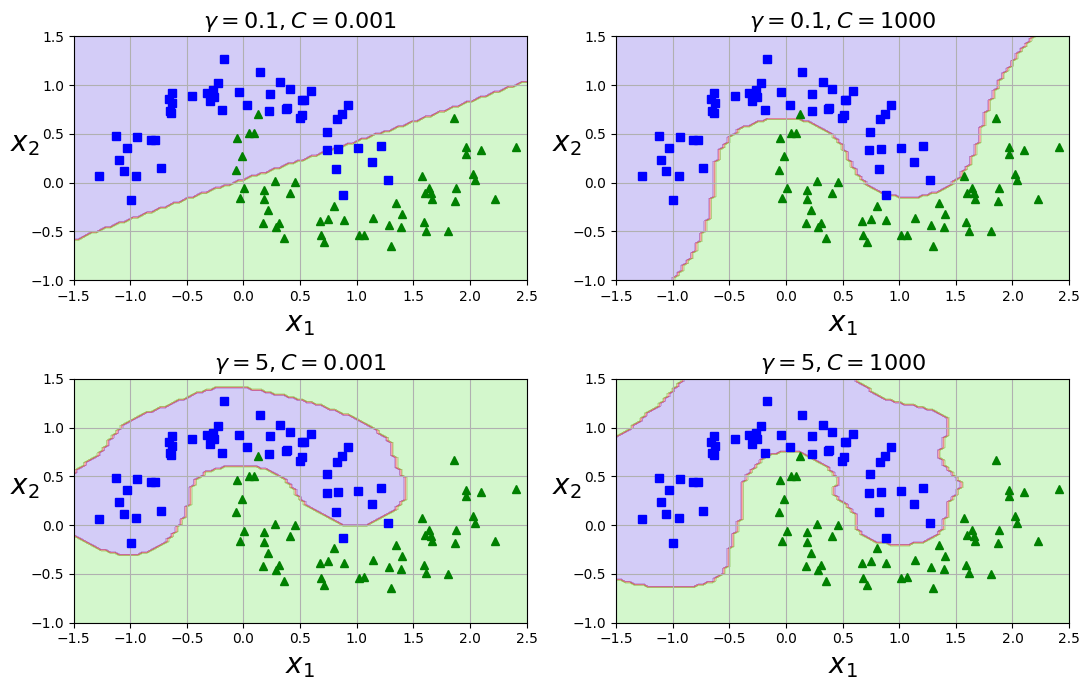

In [15]:
from sklearn.svm import SVC

gamma_params = (0.1, 5)
C_params = (0.001, 1000)
hyperparams = [(g, c) for g in gamma_params for c in C_params]

svm_clfs = []
for gamma, C in hyperparams:
    rbf_kernel_svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("svm_clf", SVC(kernel="rbf", gamma=gamma, C=C))
    ])
    rbf_kernel_svm_clf.fit(X, y)
    svm_clfs.append(rbf_kernel_svm_clf)

plt.figure(figsize=(11, 7))

for i, svm_clf in enumerate(svm_clfs):
    plt.subplot(221 + i)
    plot_predictions(svm_clf, [-1.5, 2.5, -1, 1.5])
    plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
    gamma, C = hyperparams[i]
    plt.title(fr"$\gamma = {gamma}, C = {C}$", fontsize=16)

plt.tight_layout()
plt.show()

**你会发现：**

* **$\gamma$ 越大**，边界越像“孤岛”，围着每个点转。
* **$C$ 越大**，模型对间隔违规越不能容忍，边界会变得更复杂。


## 计算复杂度

| 类             | 时间复杂度                          | 是否支持核外 | 是否需要缩放 | 核技巧 |
|---------------| ----------------------------------- | ------------ | ------------ | ------ |
| LinearSVC     | O(m × n)                            | 否           | 是           | 否     |
| SGDClassifier | O(m × n)                            | 是           | 是           | 否     |
| SVC           | O(m² × n) 到 O(m³ × n)               | 否           | 是           | 是     |

# SVM回归

在 SVM 回归中，我们的目标是让尽可能多的样本掉进那条“街道”里。

---

### 1. 核心思想：反向逻辑

* **分类任务 (SVC)**：试图在两类之间寻找最宽的街道，并限制间隔违规（即不希望样本点掉进街道）。
* **回归任务 (SVR)**：试图拟合尽可能多的实例到街道内，同时限制街道之外的违规。

### 2. 关键超参数：$\epsilon$ (Epsilon)

在分类中我们关注 $C$，而在回归中，最重要的参数是 **$\epsilon$**。它决定了这条“街道”的**宽度**。

* **$\epsilon$ 较大**：街道很宽。这意味着模型非常宽容，只有离回归线很远的点才会被视为“误差”。
* **$\epsilon$ 较小**：街道很窄。模型变得非常敏感，试图让回归线紧紧贴合每一个点。
* **不敏感特性**：只要样本点落在街道内，预测结果就不会改变。因此这种模型被称为 **$\epsilon$-不敏感（$\epsilon$-insensitive）**。

---

### SVM 回归的特点

1. **鲁棒性**：由于街道内的点不计入损失，SVR 对那些远离回归线的异常值具有天然的抵抗力。
2. **缩放依然重要**：和分类一样，SVR 在训练前也必须进行**特征缩放**。
3. **计算复杂度**：`LinearSVR` 的速度很快，但 `SVR` 在面对超大型训练集时速度会变慢。

---


In [16]:
from sklearn.svm import SVR

svm_poly_reg = SVR(kernel='poly', C=100, degree=2, epsilon=0.1)
svm_poly_reg.fit(X, y)

,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


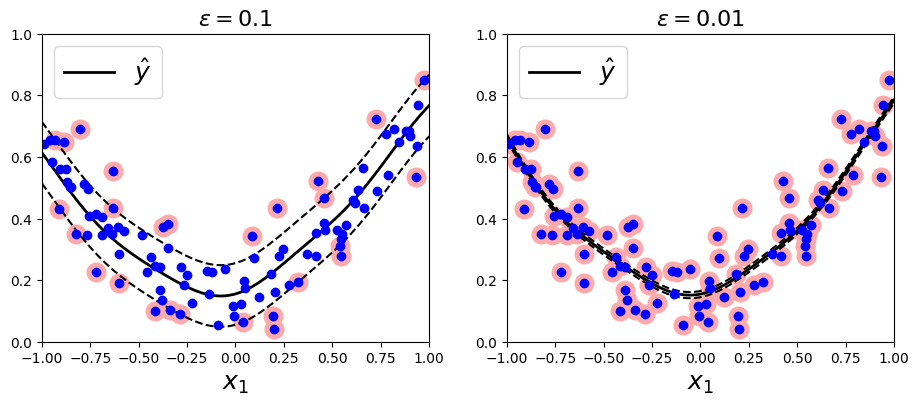

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. 生成带噪声的二次函数数据
np.random.seed(42)
m = 100
X = 2 * np.random.rand(m, 1) - 1
y = (0.2 + 0.1 * X + 0.5 * X**2 + np.random.randn(m, 1)/10).ravel()

# 2. 定义绘图函数
def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(-1, 1)
    y_pred = svm_reg.predict(x1s)
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$") # 预测线
    plt.plot(x1s, y_pred + svm_reg.named_steps['svm_reg'].epsilon, "k--") # 街道上边界
    plt.plot(x1s, y_pred - svm_reg.named_steps['svm_reg'].epsilon, "k--") # 街道下边界
    plt.scatter(X[svm_reg.named_steps['svm_reg'].support_], y[svm_reg.named_steps['svm_reg'].support_],
                s=180, facecolors='#FFAAAA') # 高亮显示支持向量
    plt.plot(X, y, "bo")
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.legend(loc="upper left", fontsize=18)
    plt.axis(axes)

# 3. 训练两个不同 epsilon 的模型 (使用 RBF 核)
svm_reg1 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_reg", SVR(kernel="rbf", gamma=1, C=100, epsilon=0.1))
])

svm_reg2 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_reg", SVR(kernel="rbf", gamma=1, C=100, epsilon=0.01))
])

svm_reg1.fit(X, y)
svm_reg2.fit(X, y)

# 4. 执行绘图
plt.figure(figsize=(11, 4))
plt.subplot(121)
plot_svm_regression(svm_reg1, X, y, [-1, 1, 0, 1])
plt.title(r"$\epsilon = 0.1$", fontsize=16)

plt.subplot(122)
plot_svm_regression(svm_reg2, X, y, [-1, 1, 0, 1])
plt.title(r"$\epsilon = 0.01$", fontsize=16)

plt.show()

# 工作原理

## 决策函数和预测

可以从**数学形式**、**判定规则**以及**训练目标**三个层面来整理。

---

### 1. 决策函数：计算“得分”

SVM 的核心是一个线性决策函数。对于一个新的输入样本 $\mathbf{x}$，它会计算一个实数值：

$$f(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b$$

* **$\mathbf{w}$（权重向量）**：决定了决策边界的法线方向。
* **$b$（偏置项）**：决定了决策边界在空间中的平移位置。
* **几何意义**：这个函数的结果可以看作是样本点到决策边界的**符号距离**。数值越大，模型对分类的信心就越强。

---

### 2. 预测规则：贴上“标签”

一旦有了决策函数的值，预测逻辑就变得非常简单。线性 SVM 分类器通过观察决策函数的结果正负来预测新实例的类别：

$$\hat{y} = \begin{cases} 0 & \text{if } \mathbf{w}^T \mathbf{x} + b < 0 \\ 1 & \text{if } \mathbf{w}^T \mathbf{x} + b \ge 0 \end{cases}$$

* **决策边界**：就是那些满足 $\mathbf{w}^T \mathbf{x} + b = 0$ 的点集。在二维空间中它是一条直线，在三维空间中是一个平面，在更高维空间中是一个超平面。
* **间隔边界**：即我们在图中看到的“街道”边缘，分别对应 $\mathbf{w}^T \mathbf{x} + b = 1$ 和 $\mathbf{w}^T \mathbf{x} + b = -1$。

---

### 3. 训练目标：让斜率更小，街道更宽

这里有一个非常巧妙的数学关系：**权重向量 $\mathbf{w}$ 的范数 $\|\mathbf{w}\|$ 越小，间隔（街道宽度）就越大**。

* **为什么要减小 $\|\mathbf{w}\|$**：为了增加街道宽度，我们需要让决策函数的斜率变得平缓。如果我们想要间隔翻倍，就需要将 $\|\mathbf{w}\|$ 减半。
* **约束条件**：在减小 $\|\mathbf{w}\|$ 的同时，我们还必须保证所有的样本点都在街道之外（或者尽量在正确的一侧），即对于所有正类样本 $y^{(i)}=1$，要求 $\mathbf{w}^T \mathbf{x}^{(i)} + b \ge 1$；对于负类样本 $y^{(i)}=0$，要求 $\mathbf{w}^T \mathbf{x}^{(i)} + b \le -1$。

---


整理 SVM 的训练目标（Training Objective），本质上是在讨论一个**受约束的优化问题**。我们的目标是找到一组参数 $\mathbf{w}$ 和 $b$，在保证分类正确的前提下，让“街道”宽度达到最大。

---

### 1. 目标：最大化边际 (Maximize the Margin)

SVM 的核心目标是让街道尽可能宽。在数学上，街道的宽度等于 $\frac{2}{\|\mathbf{w}\|}$。

* **逻辑链条**：为了使宽度 $\frac{2}{\|\mathbf{w}\|}$ 最大化，我们需要最小化 $\|\mathbf{w}\|$。
* **优化函数**：为了计算方便，我们通常最小化一个二次函数：

$$\min_{\mathbf{w}, b} \frac{1}{2} \mathbf{w}^T \mathbf{w}$$

---

### 2. 约束条件：分类必须正确

在减小 $\|\mathbf{w}\|$ 的同时，我们必须确保所有的样本点都位于街道的正确一侧。

* **硬间隔 (Hard Margin) 约束**：
* 对于正类 ($y^{(i)} = 1$)：$\mathbf{w}^T \mathbf{x}^{(i)} + b \ge 1$
* 对于负类 ($y^{(i)} = 0$)：$\mathbf{w}^T \mathbf{x}^{(i)} + b \le -1$


* **软间隔 (Soft Margin) 约束**：为了处理异常值和非线性情况，我们引入了松弛变量 $\zeta^{(i)} \ge 0$。它允许部分点进入街道甚至分错，但会产生代价。

---

### 3. 平衡艺术：$C$ 参数的作用

软间隔的最终训练目标变成了对两个相互矛盾目标的平衡：

1. **最大化间隔**：即让 $\frac{1}{2} \mathbf{w}^T \mathbf{w}$ 尽量小。
2. **最小化违规**：即让所有 $\zeta^{(i)}$ 的总和尽量小。

**超参数 $C$** 就是天平的支点：

* **小 $C$**：更在乎间隔宽度，对违规点较宽容。模型更简单，泛化能力强（但也可能欠拟合）。
* **大 $C$**：更在乎分类正确率，对违规点零容忍。模型更复杂，决策边界更弯曲（容易过拟合）。

---

### 4. 损失函数：Hinge Loss (合页损失)

从损失函数的角度看，SVM 试图最小化以下代价函数：


$$\text{Cost} = C \sum_{i=1}^{m} \max(0, 1 - t^{(i)}(\mathbf{w}^T \mathbf{x}^{(i)} + b)) + \frac{1}{2} \mathbf{w}^T \mathbf{w}$$

* **左项 (Hinge Loss)**：当点在街道之外且分类正确时，损失为 0；否则，损失随距离线性增加。
* **右项 (Regularization)**：这是 L2 正则化项，促使模型选择更宽的街道（更简单的模型）。

---

### 总结

SVM 的训练就是在**保持分类尊严**（让点在正确的位置）和**追求最大自由度**（让街道最宽）之间寻找最佳的折中点。


## 二次规划

在 SVM 的世界里，当我们确定了训练目标（即最小化 $\frac{1}{2} \mathbf{w}^T \mathbf{w}$ 并满足线性约束）后，就需要一个数学工具来求解它。这个工具就是**二次规划（Quadratic Programming, QP）**。

---

### 1. 什么是二次规划？

二次规划是一种特殊的约束优化问题。它的特点是：

* **目标函数**：是一个**二次函数**（比如含有 $w^2$ 或 $\mathbf{w}^T\mathbf{w}$ 的项）。
* **约束条件**：是**线性**的等式或不等式。

---

### 2. SVM 的标准 QP 形式

对于硬间隔 SVM，我们可以将训练目标转化为标准的 QP 参数：

* **最小化目标**：$\frac{1}{2} \mathbf{w}^T \mathbf{w}$。
* **满足约束**：对于所有 $i$，满足 $t^{(i)}(\mathbf{w}^T \mathbf{x}^{(i)} + b) \ge 1$（其中 $t^{(i)}$ 是目标标签，通常为 -1 或 1）。

这就像是在一个凹形的碗里寻找最低点，但你只能在被几道直线围成的“合法区域”内寻找。

---

### 3. 为什么 SVM 选用 QP？

1. **全局最优解**：由于 SVM 的目标函数是凸的（Convex），QP 保证了我们找到的任何局部最小值一定是**全局最小值**。你不需要担心像神经网络那样掉进局部最优陷阱。
2. **成熟的算法**：数学界已经开发了非常成熟的 QP 求解器（如 `Off-the-shelf` 优化软件），可以高效处理这些计算。

---

### 4. 实际应用中的变化

虽然你可以直接用 QP 求解器来训练 SVM，但在现代机器学习库（如 Scikit-Learn）中，情况有所不同：

* **LinearSVC**：它并不使用通用的 QP 算法，而是使用了专门为线性 SVM 优化的 **坐标下降法（Coordinate Descent）**，速度极快。
* **SVC (Kernel)**：使用了一种名为 **SMO（序列最小优化）** 的算法，它将大型 QP 问题分解为许多极小的、可以解析求解的 QP 问题。

---

### 核心笔记总结

| 维度 | SVM 的 QP 表达 |
| --- | --- |
| **目标** | 最小化 $\frac{1}{2}\|\mathbf{w}\|$ (为了最大化间隔) |
| **性质** | 凸优化问题，必有全局最优解 |
| **局限** | 纯粹的 QP 求解器在大规模数据集上计算开销较大 |


## 对偶问题



---

### 1. 什么是对偶性？

在数学优化中，每一个原始问题（Primal Problem）都有一个与之对应的对偶问题。

* **原始问题**：直接寻找最优的 $\mathbf{w}$ 和 $b$。
* **对偶问题**：寻找一组拉格朗日乘子 $\alpha$（每个样本点对应一个 $\alpha^{(i)}$）。通过最大化关于 $\alpha$ 的函数，我们可以间接得到原始问题的解。

---

### 2. SVM 对偶问题的数学表达

对于线性可分的情况，对偶训练目标是找到一个向量 $\mathbf{\alpha}$，使得以下函数最大化：

$$\max_{\mathbf{\alpha}} \sum_{i=1}^{m} \alpha^{(i)} - \frac{1}{2} \sum_{i=1}^{m} \sum_{j=1}^{m} \alpha^{(i)} \alpha^{(j)} t^{(i)} t^{(j)} (\mathbf{x}^{(i)})^T \mathbf{x}^{(j)}$$

**约束条件**：

* $\alpha^{(i)} \ge 0$
* $\sum_{i=1}^{m} \alpha^{(i)} t^{(i)} = 0$

---

### 3. 对偶问题的三大核心意义

#### A. 揭示了支持向量的本质

求解对偶问题后，你会发现绝大多数 $\alpha^{(i)}$ 都等于 0。

* 只有那些 $\alpha^{(i)} > 0$ 的样本点才是**支持向量**。
* 最终的 $\mathbf{w}$ 只与这些支持向量有关：$\mathbf{w} = \sum_{i=1}^{m} \alpha^{(i)} t^{(i)} \mathbf{x}^{(i)}$。

#### B. 点积是关键（核技巧的温床）

观察公式你会发现，数据 $\mathbf{x}$ 仅以**点积 $(\mathbf{x}^{(i)})^T \mathbf{x}^{(j)}$** 的形式出现。

* 这意味着我们不需要知道样本的具体坐标，只需要知道它们之间的“相似度”（点积）。
* **核技巧**正是利用了这一点：用核函数 $K(\mathbf{x}^{(i)}, \mathbf{x}^{(j)})$ 替换这个点积，从而实现向高维空间的隐式映射。

#### C. 计算效率

当特征数量 $n$ 远大于样本数量 $m$ 时，求解对偶问题通常比原始问题更高效。

---

### 总结：原始 vs 对偶

| 特性 | 原始问题 (Primal) | 对偶问题 (Dual) |
| --- | --- | --- |
| **求解对象** | $\mathbf{w}, b$ | $\alpha$ |
| **参数数量** | 取决于特征维度 $n$ | 取决于样本数量 $m$ |
| **支持核技巧** | 不支持（或不直接） | **完美支持** |
| **适用场景** | 线性 SVM, $m$ 很大时 | 非线性 SVM, 核函数场景 |

---


## 核化SVM

在整理了**对偶问题**之后，**核化 SVM（Kernelized SVM）** 就是水到渠成的最后一步。它是 SVM 能够处理极度复杂的非线性边界，却依然保持高效计算的关键所在。

---

### 1. 核心概念：什么是“核”？

核（Kernel）本质上是一个**快捷方式**。

* **背景**：当原始特征 $x$ 无法线性可分时，我们需要通过函数 $\phi(x)$ 将其映射到高维空间。
* **核函数 $K(\mathbf{a}, \mathbf{b})$**：它能直接计算出映射后的向量 $\phi(\mathbf{a})$ 和 $\phi(\mathbf{b})$ 的**点积**，而**不需要**真的去计算 $\phi(\mathbf{a})$ 和 $\phi(\mathbf{b})$ 本身。

---

### 2. 为什么需要核技巧？

* **效率革命**：在处理高阶多项式或高斯 RBF 时，映射后的维度可能非常高（甚至是无限维）。
* **避开爆炸**：核技巧让你在低维空间进行简单的计算，就能得到高维空间才有的复杂分类效果，从而完美避开了“维度灾难”。

---

### 3. 常见核函数总结


| 核函数名称 | 公式表达式 $K(\mathbf{a}, \mathbf{b})$ | 适用场景 |
| --- | --- | --- |
| **线性核 (Linear)** | $\mathbf{a}^T \mathbf{b}$ | 数据量巨大，或特征多且线性可分 |
| **多项式核 (Poly)** | $(\gamma \mathbf{a}^T \mathbf{b} + r)^d$ | 处理特征之间的组合关系（如 $x_1x_2$） |
| **高斯 RBF 核** | $ \exp(-\gamma \|\mathbf{a} - \mathbf{b}\|^2)$ | 通用性最强，处理各种复杂的非线性边界 |
| **Sigmoid 核** | $\tanh(\gamma \mathbf{a}^T \mathbf{b} + r)$ | 类似于神经网络中的激活函数 |

---

### 4. 预测阶段的“隐身”

在使用核化 SVM 进行预测时，决策函数也发生了变化。对于新样本 $\mathbf{x}$，预测不再依赖 $\mathbf{w}$（因为在高维空间 $\mathbf{w}$ 甚至无法显式表示），而是依赖于它与**支持向量**的核函数计算：

$$\hat{y} = \text{sgn}\left( \sum_{i \in SV} \alpha^{(i)} t^{(i)} K(\mathbf{x}^{(i)}, \mathbf{x}) + b \right)$$

* **结论**：预测只需要计算新样本与少数几个支持向量之间的“核相似度”。

---

### 最终总结笔记

1. **对偶问题是前提**：没有对偶公式中的点积形式，核技巧就无处施展。
2. **Mercer 定理**：只要一个函数满足 Mercer 条件（半正定），它就可以被当作核函数使用。
3. **计算代价**：虽然核技巧很神奇，但如果训练样本量 $m$ 达到几十万量级，核化 SVM 的计算（SMO 算法）会变得非常缓慢。
